In [482]:
import requests
import json
import xml.etree.ElementTree as ET
import pandas as pd
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
import torch
import accelerate
import time
from rapidfuzz import process, fuzz
import re
import networkx as nx
import matplotlib.pyplot as plt
import pickle

In [488]:
all_stations_url = "http://api.irishrail.ie/realtime/realtime.asmx/getAllStationsXML"
start = time.time()
response = requests.get(all_stations_url)
end = time.time()
print(end - start)
response.status_code

0.20435786247253418


200

In [59]:
root = ET.fromstring(response.content)

In [356]:
stations = []

for item in root.findall(".//{*}objStation"):
    station = {
        "StationDesc": item.findtext("{*}StationDesc"),
        "StationLatitude": item.findtext("{*}StationLatitude"),
        "StationLongitude": item.findtext("{*}StationLongitude"),
        "StationCode": item.findtext("{*}StationCode"),
        "StationId": item.findtext("{*}StationId"),
    }

    stations.append(station)

In [357]:
stations_df = pd.DataFrame(stations)

In [358]:
53.351252	-6.249704

47.101548

In [371]:
stations_df['normalized_station_name'] = stations_df['StationDesc'].apply(normalize_name)
stations_df[stations_df['StationDesc'] == 'Navan Road Parkway']

,StationDesc,StationLatitude,StationLongitude,StationCode,StationId,normalized_station_name
50,Navan Road Parkway,53.3777,-6.34591,PHNPK,89,navanroadparkway


# GTFS files

In [66]:
stops = pd.read_csv("gtfs/stops.txt")
routes = pd.read_csv("gtfs/routes.txt")
trips = pd.read_csv("gtfs/trips.txt")
stop_times = pd.read_csv("gtfs/stop_times.txt")
agency = pd.read_csv("gtfs/agency.txt")

In [89]:
routes = routes[routes['agency_id']=='IR'].drop(['route_desc', 'route_type', 'route_url', 'route_color', 'route_text_color'], axis=1)
routes

,route_id,agency_id,route_short_name,route_long_name
379,BRAY-HOWTH-I,IR,DART,Bray - Howth
380,DUB-BFT-I,IR,rail,Belfast - Dublin
381,DUB-BFT-O,IR,rail,Dublin - Belfast
382,DUB-CORK-O,IR,InterCity,Dublin - Cork
383,DUB-DRO/DUN-O,IR,rail,Dublin - Drogheda/Dundalk
384,DUB-EUROPORT-I,IR,rail,Dublin - Europort
385,DUB-GALWAY-O,IR,rail,Dublin - Galway
386,DUB-LIMERICK-I,IR,rail,Dublin - Limerick
387,DUB-MAYNOOTH-O,IR,rail,Dublin - Maynooth
388,DUB-NEN-LIM-I,IR,rail,Dublin - Limerick via Nenagh


In [150]:
routes_list = routes['route_id'].str.lower().to_list()
routes_list

['bray-howth-i',
 'dub-bft-i',
 'dub-bft-o',
 'dub-cork-o',
 'dub-dro/dun-o',
 'dub-europort-i',
 'dub-galway-o',
 'dub-limerick-i',
 'dub-maynooth-o',
 'dub-nen-lim-i',
 'dub-portlaois-o',
 'dub-sligo-o',
 'dub-tralee-o',
 'dub-waterford-i',
 'dub-westport-i',
 'galway-lim-i',
 'lim-ballybrop-i',
 'limerick-wat-o',
 'mal-cobh-o']

In [354]:
ir_stops = (
    stops.loc[
        stops["stop_id"].str.contains("IR", na=False)
        | stops["stop_id"].isin(["8220WBROK","8220KISHO"]),
        ["stop_id", "stop_name", "stop_lat", "stop_lon"]
        ].reset_index(drop=True)
)

ir_stops['normalized_stop_name'] = (
    ir_stops['stop_name']
    .str.replace(r"\b(?:Station|Dublin)\b", "", case=False, regex=True)
    .str.replace(r"[\s()\[\]{}]+", "", regex=True)
    .str.lower()
)
ir_stops

,stop_id,stop_name,stop_lat,stop_lon,normalized_stop_name
0,7020IR0037,Lisburn,54.513863,-6.045132,lisburn
1,7020IR2162,Belfast,54.594684,-5.939831,belfast
2,7040IR0042,Newry,54.188659,-6.362413,newry
3,7040IR0045,Portadown,54.424993,-6.445312,portadown
4,7040IR0090,Lurgan,54.467011,-6.338528,lurgan
...,...,...,...,...,...
147,8500IR0090,Boyle,53.967594,-8.304383,boyle
148,8500IR0091,Castlerea,53.761530,-8.485715,castlerea
149,8510IR0092,Sligo (MacDiarmada),54.271956,-8.481925,sligomacdiarmada
150,8510IR0093,Ballymote,54.088241,-8.521550,ballymote


In [367]:
ir_stops["station_code"] = ir_stops["normalized_stop_name"].apply(
    lambda name: stations_df.loc[
        process.extractOne(
            name,
            stations_df["normalized_station_name"],
            scorer=fuzz.ratio,
        )[2],
        "StationCode",
    ]
)
ir_stops

,stop_id,stop_name,stop_lat,stop_lon,normalized_stop_name,station_code
0,7020IR0037,Lisburn,54.513863,-6.045132,lisburn,LBURN
1,7020IR2162,Belfast,54.594684,-5.939831,belfast,BFSTC
2,7040IR0042,Newry,54.188659,-6.362413,newry,NEWRY
3,7040IR0045,Portadown,54.424993,-6.445312,portadown,PDOWN
4,7040IR0090,Lurgan,54.467011,-6.338528,lurgan,LURGN
...,...,...,...,...,...,...
147,8500IR0090,Boyle,53.967594,-8.304383,boyle,BOYLE
148,8500IR0091,Castlerea,53.761530,-8.485715,castlerea,CSREA
149,8510IR0092,Sligo (MacDiarmada),54.271956,-8.481925,sligomacdiarmada,SLIGO
150,8510IR0093,Ballymote,54.088241,-8.521550,ballymote,BMOTE


In [368]:
ir_stops.to_csv("all_stations.csv", index=False)

# Matching station with rapidfuzz, in case LLM makes a mistake

In [344]:
normalize_name = lambda name: re.sub(r"[\s()\[\]{}]+", "", name.lower())

In [365]:
request = "lisbprn"
match = process.extractOne(
    normalize_name(request),
    ir_stops['normalized_stop_name'],
    scorer = fuzz.ratio
)
match

('lisburn', 85.71428571428572, 0)

In [409]:
ir_stop_times

,trip_id,arrival_time,departure_time,stop_id,stop_sequence
0,5866_10000,10:35:00,10:35:00,8260IR0063,1
1,5866_10000,10:39:00,10:40:00,8230IR0128,2
2,5866_10000,10:42:00,10:43:00,8220KISHO,3
3,5866_10000,10:45:00,10:46:00,8230IR0036,4
4,5866_10000,10:49:00,10:50:00,8220IR0129,5
...,...,...,...,...,...
39459,5866_9999,11:21:00,11:22:00,8230IR0128,8
39460,5866_9999,11:24:00,11:25:00,8220KISHO,9
39461,5866_9999,11:27:00,11:28:00,8230IR0036,10
39462,5866_9999,11:30:00,11:31:00,8220IR0129,11


In [378]:
ir_stop_times = (
    stop_times.loc[
        stop_times['trip_id'].isin(ir_trips_id_list),
        ['trip_id', 'arrival_time', 'departure_time', 'stop_id', 'stop_sequence']
    ].reset_index(drop=True)
)

ir_stop_grouped_by_trip = (
    ir_stop_times
    .sort_values(['trip_id', 'stop_sequence'])
    .groupby('trip_id', as_index=False)
    .agg({
        "stop_id": list,
    })
)

ir_stop_grouped_by_trip

,trip_id,stop_id
0,5866_10000,"[8260IR0063, 8230IR0128, 8220KISHO, 8230IR0036..."
1,5866_10005,"[8280IR0068, 8280IR0067, 8260IR0059, 8260IR005..."
2,5866_10006,"[8280IR0068, 8280IR0067, 8260IR0059, 8260IR005..."
3,5866_1001,"[8240IR0017, 8240IR0024, 8240IR0140, 8240IR002..."
4,5866_10011,"[8280IR0068, 8280IR0067, 8260IR0059, 8260IR005..."
...,...,...
2919,5866_9987,"[8260IR0054, 8260IR0060, 8260IR0063, 8230IR012..."
2920,5866_9988,"[8280IR0068, 8280IR0067, 8260IR0059, 8260IR005..."
2921,5866_9989,"[8280IR0068, 8280IR0067, 8260IR0059, 8260IR005..."
2922,5866_9994,"[8280IR0068, 8280IR0067, 8260IR0059, 8260IR005..."


In [431]:
ir_trips = (
    trips.loc[
        trips['route_id'].str.lower().isin(routes_list),
        ['route_id', 'service_id', "trip_id", 'trip_headsign', 'trip_short_name', 'direction_id']
    ].reset_index(drop=True)
)

ir_trips_and_sequences = ir_trips.merge(
    ir_stop_grouped_by_trip,
    on='trip_id',
    how='left',
)

ir_trips_and_sequences['stop_pattern'] = (
    ir_trips_and_sequences['stop_id'].apply(tuple)
)

ir_trips_and_sequences['pattern_id'] = (
    ir_trips_and_sequences
    .groupby(
        ['route_id', 'direction_id', 'stop_pattern'],
        sort=False
    )
    .ngroup()
)
ir_trips_and_sequences

,route_id,service_id,trip_id,trip_headsign,trip_short_name,direction_id,stop_id,stop_pattern,pattern_id
0,DUB-PORTLAOIS-O,303,5866_10000,Grand Canal Dock,P407,1,"[8260IR0063, 8230IR0128, 8220KISHO, 8230IR0036...","(8260IR0063, 8230IR0128, 8220KISHO, 8230IR0036...",0
1,DUB-PORTLAOIS-O,329,5866_10005,Dublin Heuston,P201,1,"[8280IR0068, 8280IR0067, 8260IR0059, 8260IR005...","(8280IR0068, 8280IR0067, 8260IR0059, 8260IR005...",1
2,DUB-PORTLAOIS-O,350,5866_10006,Dublin Heuston,P213,1,"[8280IR0068, 8280IR0067, 8260IR0059, 8260IR005...","(8280IR0068, 8280IR0067, 8260IR0059, 8260IR005...",1
3,BRAY-HOWTH-I,303,5866_1001,Bray (Daly),E239,1,"[8240IR0017, 8240IR0024, 8240IR0140, 8240IR002...","(8240IR0017, 8240IR0024, 8240IR0140, 8240IR002...",2
4,DUB-PORTLAOIS-O,277,5866_10011,Dublin Heuston,P202,1,"[8280IR0068, 8280IR0067, 8260IR0059, 8260IR005...","(8280IR0068, 8280IR0067, 8260IR0059, 8260IR005...",1
...,...,...,...,...,...,...,...,...,...
2919,DUB-PORTLAOIS-O,303,5866_9987,Grand Canal Dock,P406,1,"[8260IR0054, 8260IR0060, 8260IR0063, 8230IR012...","(8260IR0054, 8260IR0060, 8260IR0063, 8230IR012...",3
2920,DUB-PORTLAOIS-O,353,5866_9988,Dublin Heuston,P209,1,"[8280IR0068, 8280IR0067, 8260IR0059, 8260IR005...","(8280IR0068, 8280IR0067, 8260IR0059, 8260IR005...",1
2921,DUB-PORTLAOIS-O,355,5866_9989,Dublin Heuston,P209,1,"[8280IR0068, 8280IR0067, 8260IR0059, 8260IR005...","(8280IR0068, 8280IR0067, 8260IR0059, 8260IR005...",1
2922,DUB-PORTLAOIS-O,350,5866_9994,Dublin Heuston,P211,1,"[8280IR0068, 8280IR0067, 8260IR0059, 8260IR005...","(8280IR0068, 8280IR0067, 8260IR0059, 8260IR005...",1


In [432]:
trip_patterns = (
    ir_trips_and_sequences[
        [
            'pattern_id',
            'route_id',
            'direction_id',
            'stop_pattern',
        ]
    ]
    .drop_duplicates('pattern_id')
    .reset_index(drop=True)
)
trip_patterns['origin_stop_id'] = (
    trip_patterns['stop_pattern'].str[0]
)
trip_patterns['destination_stop_id'] = (
    trip_patterns['stop_pattern'].str[-1]
)

trip_patterns

,pattern_id,route_id,direction_id,stop_pattern,origin_stop_id,destination_stop_id
0,0,DUB-PORTLAOIS-O,1,"(8260IR0063, 8230IR0128, 8220KISHO, 8230IR0036...",8260IR0063,8220IR0135
1,1,DUB-PORTLAOIS-O,1,"(8280IR0068, 8280IR0067, 8260IR0059, 8260IR005...",8280IR0068,8220IR0132
2,2,BRAY-HOWTH-I,1,"(8240IR0017, 8240IR0024, 8240IR0140, 8240IR002...",8240IR0017,8350IR0123
3,3,DUB-PORTLAOIS-O,1,"(8260IR0054, 8260IR0060, 8260IR0063, 8230IR012...",8260IR0054,8220IR0135
4,4,DUB-PORTLAOIS-O,1,"(8260IR0063, 8230IR0128, 8220KISHO, 8230IR0036...",8260IR0063,8220IR0007
...,...,...,...,...,...,...
332,332,DUB-MAYNOOTH-O,0,"(8220IR0135, 8220IR0134, 8220IR0025, 8220IR000...",8220IR0135,8290IR0072
333,333,DUB-MAYNOOTH-O,0,"(8350IR0123, 8250IR0124, 8250IR0030, 8220IR003...",8350IR0123,8260IR0058
334,334,DUB-MAYNOOTH-O,0,"(8220IR0007, 8220IR0027, 8220IR0026, 8220IR001...",8220IR0007,8330IR0108
335,335,DUB-PORTLAOIS-O,1,"(8280IR0068, 8280IR0067, 8260IR0059, 8260IR005...",8280IR0068,8220IR0132


In [433]:
hub_stop_ids = pd.unique(
    pd.concat([
        trip_patterns['origin_stop_id'],
        trip_patterns['destination_stop_id']
    ])
)
hub_stop_ids

array(['8260IR0063', '8280IR0068', '8240IR0017', '8260IR0054',
       '8220IR0132', '8220IR0135', '8220IR0007', '8240IR0020',
       '8510IR0092', '8390IR0052', '8370IR0126', '8380IR0004',
       '8440IR0106', '8210IR0002', '8260IR0057', '8490IR0076',
       '8330IR0107', '8490IR0078', '8490IR0077', '8460IR0044',
       '8360IR0003', '8400IR0127', '8430IR0100', '8420IR0095',
       '8280IR0066', '8380IR0012', '8380IR0142', '8250IR0124',
       '8220IR0133', '8350IR0123', '8350IR0122', '8220IR0134',
       '7020IR2162', '8380IR0006', '8300IR0075', '8300IR0074',
       '8340IR0113', '8340IR0110', '8340IR0112', '8470IR0043',
       '8320IR0087', '8420IR0098', '8290IR0072', '8260IR0058',
       '8310IR0083', '8240IR0041', '8220IR0137', '8330IR0108'],
      dtype=object)

In [435]:
hub_stations = (
    ir_stops[
        ir_stops['stop_id'].isin(hub_stop_ids)
    ]
    .drop_duplicates('stop_id')
    .reset_index(drop=True)
)
hub_stations.head()

,stop_id,stop_name,stop_lat,stop_lon,normalized_stop_name,station_code
0,7020IR2162,Belfast,54.594684,-5.939831,belfast,BFSTC
1,8210IR0002,Carlow,52.840788,-6.922622,carlow,CRLOW
2,8220IR0007,Connolly,53.351252,-6.249704,connolly,CNLLY
3,8220IR0132,Dublin Heuston,53.346404,-6.293487,heuston,HSTON
4,8220IR0133,Lansdowne Road,53.333963,-6.229191,lansdowneroad,LDWNE


In [467]:
hub_stop_ids = set(hub_stations["stop_id"])

hub_edges = []

for row in trip_patterns.itertuples():
    stops = list(row.stop_pattern)

    hubs_on_trip = [
        stop for stop in stops
        if stop in hub_stop_ids
    ]

    hub_edges.extend(
        {
            "pattern_id": row.pattern_id,
            "route_id": row.route_id,
            "origin_stop_id": start,
            "destination_stop_id": end,
        }
        for start, end in zip(hubs_on_trip, hubs_on_trip[1:])
    )

hub_edges = (
    pd.DataFrame(hub_edges)
    .drop_duplicates(
        ["route_id", "origin_stop_id", "destination_stop_id"]
    )
    .reset_index(drop=True)
)
hub_edges

,pattern_id,route_id,origin_stop_id,destination_stop_id
0,0,DUB-PORTLAOIS-O,8260IR0063,8220IR0007
1,0,DUB-PORTLAOIS-O,8220IR0007,8220IR0134
2,0,DUB-PORTLAOIS-O,8220IR0134,8220IR0135
3,1,DUB-PORTLAOIS-O,8280IR0068,8260IR0057
4,1,DUB-PORTLAOIS-O,8260IR0057,8260IR0054
...,...,...,...,...
269,332,DUB-MAYNOOTH-O,8330IR0108,8290IR0072
270,333,DUB-MAYNOOTH-O,8350IR0123,8250IR0124
271,333,DUB-MAYNOOTH-O,8250IR0124,8220IR0133
272,333,DUB-MAYNOOTH-O,8220IR0133,8220IR0135


In [470]:
stop_name_map = hub_stations.set_index("stop_id")["stop_name"]

hub_edges["origin_name"] = hub_edges["origin_stop_id"].map(stop_name_map)
hub_edges["destination_name"] = hub_edges["destination_stop_id"].map(stop_name_map)

hub_edges

,pattern_id,route_id,origin_stop_id,destination_stop_id,origin_name,destination_name
0,0,DUB-PORTLAOIS-O,8260IR0063,8220IR0007,Hazelhatch and Celbridge,Connolly
1,0,DUB-PORTLAOIS-O,8220IR0007,8220IR0134,Connolly,Dublin Pearse
2,0,DUB-PORTLAOIS-O,8220IR0134,8220IR0135,Dublin Pearse,Grand Canal Dock
3,1,DUB-PORTLAOIS-O,8280IR0068,8260IR0057,Portlaoise,Kildare
4,1,DUB-PORTLAOIS-O,8260IR0057,8260IR0054,Kildare,Newbridge
...,...,...,...,...,...,...
269,332,DUB-MAYNOOTH-O,8330IR0108,8290IR0072,Mullingar,Longford
270,333,DUB-MAYNOOTH-O,8350IR0123,8250IR0124,Bray (Daly),Dun Laoghaire (Mallin)
271,333,DUB-MAYNOOTH-O,8250IR0124,8220IR0133,Dun Laoghaire (Mallin),Lansdowne Road
272,333,DUB-MAYNOOTH-O,8220IR0133,8220IR0135,Lansdowne Road,Grand Canal Dock


In [479]:
hub_map = nx.MultiGraph()

for row in hub_edges.itertuples():
    hub_map.add_edge(
        row.origin_stop_id,
        row.destination_stop_id,
        route_id=row.route_id,
    )

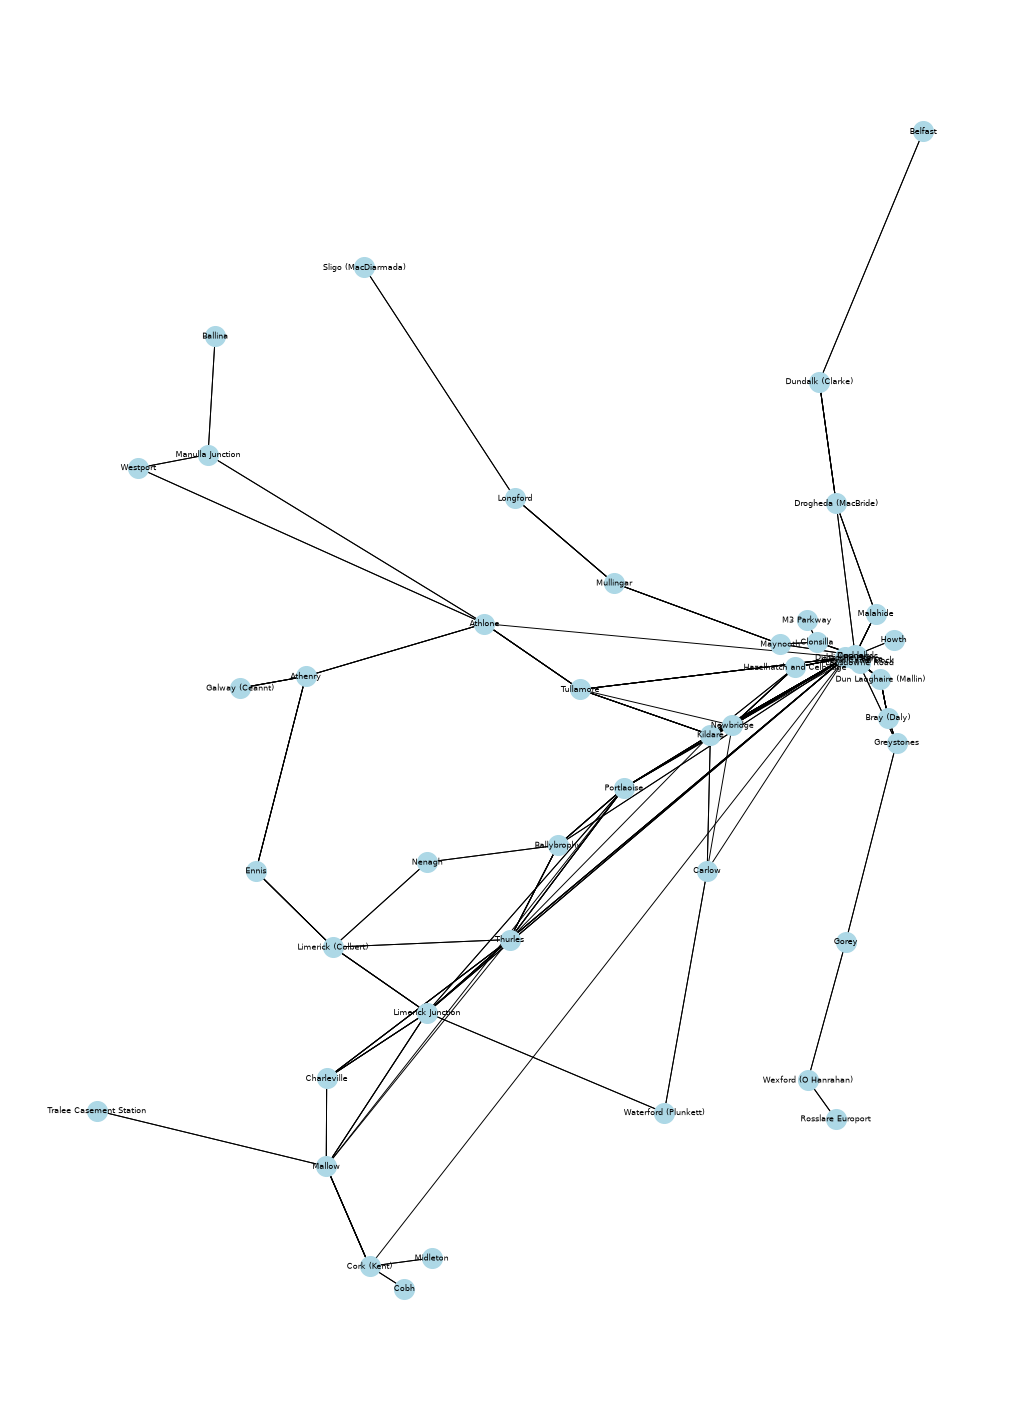

In [474]:
positions = (
    ir_stops
    .set_index("stop_id")[["stop_lon", "stop_lat"]]
    .apply(tuple, axis=1)
    .to_dict()
)

station_names = (
    ir_stops[
        ir_stops['stop_id'].isin(hub_map.nodes)
    ]
    .set_index("stop_id")["stop_name"]
    .to_dict()
)

plt.figure(figsize=(10, 14))

nx.draw(
    hub_map,
    positions,
    labels=station_names,
    with_labels=True,
    node_size=200,
    node_color="lightblue",
    font_size=6,
    arrows=True,
    width=0.7,
)

plt.axis("off")
plt.show()

# LLM init and promprting

In [2]:
model_name = "Qwen/Qwen2.5-3B-Instruct"

quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)

tokenizer = AutoTokenizer.from_pretrained(model_name)

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=quantization_config,
    device_map="auto",
)

W0831 00:30:32.438000 27668 site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels
Loading weights: 100%|██████████| 434/434 [00:08<00:00, 52.71it/s]


In [82]:
messages = [
    {
        "role": "system",
        "content": (
            "Extract information from the user's Irish Rail delay request. "
            "Return only valid JSON with exactly these fields: "
            '"departure_station", "destination_station"'
            "Use null for any value the user did not provide. "
            "Do not invent values. "
            'Normalize "Dublin" to "Dublin Connolly". '
            "Do not include Markdown or an explanation."
        ),
    },
    {
        "role": "user",
        "content": (
            "I am travelling from Drogheda to Dublin. "
            "Are there any delays?"
        ),
    },
]
model_inputs = tokenizer.apply_chat_template(
    messages,
    tokenize=True,
    add_generation_prompt=True,
    return_tensors="pt",
    return_dict=True,
).to(model.device)

In [85]:
# Synchronize before measuring GPU execution
if torch.cuda.is_available():
    torch.cuda.synchronize()

# timing the response
start_time = time.perf_counter()

with torch.inference_mode():
    generated_ids = model.generate(
        **model_inputs,
        max_new_tokens=100,
        do_sample=False,
        use_cache=True,
    )

# Wait for GPU operations to finish before stopping the timer
if torch.cuda.is_available():
    torch.cuda.synchronize()

load_time = time.perf_counter() - start_time

new_tokens = generated_ids[:, model_inputs["input_ids"].shape[1]:]

response = tokenizer.batch_decode(
    new_tokens,
    skip_special_tokens=True,
)[0].strip()

print(response)

I can provide some general information about the Northern Line and the Dart services in Dublin, but I recommend checking the official Dublin Bus and Irish Rail websites for the most accurate and up-to-date information.

### Northern Line:
The Northern Line is a commuter rail service operated by Irish Rail. It runs from Connolly Station in Dublin city center to Dundalk in County Louth. The line passes through various stations including Heuston, Clontarf, and Portrane.

### Dart Service:
The Dart is a bus service operated by Dublin Bus that connects Dublin city center with the Northside and Southside of Dublin. It operates on a network of routes that include the Dart Line 1 (Dublin Heuston to Howth), Dart Line 2 (Dublin Heuston to Malahide), and Dart Line 3 (Dublin Heuston to Ballymun).

### Transfers Between Northern Line and Dart:
Transfers between the Northern Line and the Dart can be made at Heuston Station, which serves as a hub for both services. Here’s how you can transfer:

1. **

In [86]:
input_length = model_inputs["input_ids"].shape[1]
output_length = generated_ids.shape[1] - input_length
tokens_per_second = output_length / load_time

print(f"Input tokens: {input_length}")
print(f"Generated tokens: {output_length}")
print(f"Inference time: {load_time:.2f} seconds")
print(f"Generation speed: {tokens_per_second:.2f} tokens/second")

Input tokens: 46
Generated tokens: 472
Inference time: 48.74 seconds
Generation speed: 9.68 tokens/second
